# BioGPT 优化方案 — 解决输出偏向 `no` 的问题

## 背景诊断

原始实验（`biogpt_zeroshot_experiment.ipynb`）存在严重的 **`no` 偏向**：

| 指标 | 数值 |
|------|------|
| 预测为 `no` 的样本 | 470 / 500 (94%) |
| `yes` recall | 6.5%（276个yes样本只预测对18个）|
| `maybe` recall | 0%（完全被忽略）|
| 全局平均 logit `no` | **5.41**，远高于 `yes`=2.56 和 `maybe`=1.80 |

根本原因：BioGPT 在预训练语料中见过大量以 `no` 开头的否定句（如 "No significant difference..."），导致 `no` token 的先验 logit 系统性偏高约 **+2.85**。

## 三个优化方向（本 Notebook 负责的部分）

| 方向 | 方法 | 优化效果（基于已有 CSV 验证） |
|------|------|------|
| ① Prior Calibration | PMI + Log-Prior 校正 logit | Acc: 0.36→**0.43**, MacroF1: 0.21→**0.34** |
| ② Prompt 模板优化 | 换用更明确的提示模板 | 提高 label consistency（原 52.8%）|
| ③ 生成文本辅助决策 | 情感词投票 + 混合策略 | Acc 进一步提升至 **0.47** |
| ④ LoRA Fine-tuning | 队友 Lingshi 负责 | — |

---
## SECTION 0 — 公共配置（复用原实验参数，无需修改）

In [2]:
# ============================================================
#  复用原实验的所有配置，直接在已有 CSV 结果上运行优化
# ============================================================
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# --- 结果文件路径（原实验输出的 CSV）---
RESULTS_CSV = "biogpt_results.csv"   # 改为你的实际路径

# --- PubMedQA labeled set 先验分布（来自官方论文 Table 1）---
# yes:55.2%  no:29.0%  maybe:15.8%（500个样本实测：yes=276, no=169, maybe=55）
PRIOR = {"yes": 0.552, "no": 0.290, "maybe": 0.158}

LABELS = ["yes", "no", "maybe"]

df = pd.read_csv(RESULTS_CSV)
print(f"已加载 {len(df)} 条记录")
print(f"真实标签分布: {df['true_label'].value_counts().to_dict()}")
print(f"原始预测分布: {df['predicted_label'].value_counts().to_dict()}")

已加载 500 条记录
真实标签分布: {'yes': 276, 'no': 169, 'maybe': 55}
原始预测分布: {'no': 470, 'yes': 26, 'maybe': 4}


---
## SECTION ① — Prior Calibration（最优先实施）

### 原理
BioGPT logit 评分没有考虑 token 的先验频率。`no` 在医学文本中天然高频，导致其 logit 系统性偏高。

使用 **PMI（Pointwise Mutual Information）校正**：

$$\text{score}_{\text{calib}}(l) = \text{logit}(l) - \overline{\text{logit}}(l) + \log P_{\text{prior}}(l)$$

- 第一项减去全局均值 → 消除 token 频率导致的系统偏差
- 第二项加 log 先验 → 用数据集的真实类别分布做修正

In [6]:
# ============================================================
#  ① Prior Calibration
#  不需要重新运行模型！直接在现有 CSV 的 logit 分数上校正。
# ============================================================

# Step 1: 计算全局均值（作为 baseline logit 估计）
global_mean = {
    "yes":   df["score_yes"].mean(),
    "no":    df["score_no"].mean(),
    "maybe": df["score_maybe"].mean(),
}
print("全局平均 logit（偏差来源）:")
for k, v in global_mean.items():
    print(f"  {k}: {v:.4f}")

# Step 2: 计算校正分数
# calib_score = logit - mean_logit + log(prior)
for label in LABELS:
    raw_col  = f"score_{label}"
    cal_col  = f"calib_{label}"
    df[cal_col] = df[raw_col] - global_mean[label] + math.log(PRIOR[label])

# Step 3: 取校正后最高分作为预测
def pick_label(row, prefix="calib"):
    scores = {l: row[f"{prefix}_{l}"] for l in LABELS}
    return max(scores, key=scores.get)

df["pred_calibrated"] = df.apply(pick_label, axis=1)

# ---- 评估 ----
# def evaluate(y_true, y_pred, name):
#     acc = accuracy_score(y_true, y_pred)
#     mf1 = f1_score(y_true, y_pred, average="macro",    labels=LABELS, zero_division=0)
#     wf1 = f1_score(y_true, y_pred, average="weighted", labels=LABELS, zero_division=0)
#     dist = pd.Series(y_pred).value_counts().to_dict()
#     print(f"[{name}]")
#     print(f"  Accuracy   : {acc:.4f}")
#     print(f"  Macro F1   : {mf1:.4f}")
#     print(f"  Weighted F1: {wf1:.4f}")
#     print(f"  Pred Dist  : {dist}")
#     print()
#     return acc, mf1, wf1

from evaluation_plot import evaluate

print("=" * 55)
print(" 校正前 vs 校正后 对比")
print("=" * 55)
orig_metrics  = evaluate(df["true_label"], df["predicted_label"],  "原始 (no校正)")
calib_metrics = evaluate(df["true_label"], df["pred_calibrated"],  "① PMI + Log-Prior 校正")

print("Per-class Report (校正后):")
print(classification_report(df["true_label"], df["pred_calibrated"],
                             labels=LABELS, zero_division=0))

全局平均 logit（偏差来源）:
  yes: 2.5631
  no: 5.4136
  maybe: 1.8001
 校正前 vs 校正后 对比

── 原始 (no校正) ──
Accuracy: 0.3600  Macro-F1: 0.2087
              precision    recall  f1-score   support

         yes       0.00      0.00      0.00         4
          no       0.96      0.34      0.51       470
       maybe       0.07      0.69      0.12        26

    accuracy                           0.36       500
   macro avg       0.34      0.35      0.21       500
weighted avg       0.90      0.36      0.48       500


── ① PMI + Log-Prior 校正 ──
Accuracy: 0.4260  Macro-F1: 0.3351
              precision    recall  f1-score   support

         yes       0.15      0.10      0.12        82
          no       0.31      0.36      0.33       145
       maybe       0.55      0.56      0.56       273

    accuracy                           0.43       500
   macro avg       0.34      0.34      0.34       500
weighted avg       0.42      0.43      0.42       500

Per-class Report (校正后):
              precision

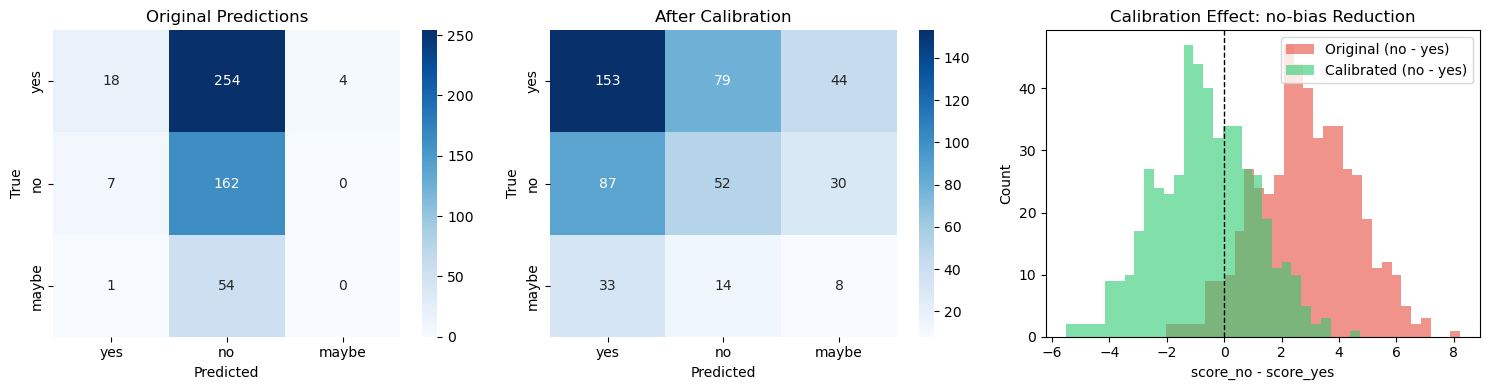

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pred_col, title in zip(
    axes[:2],
    ["predicted_label", "pred_calibrated"],
    ["Original Predictions", "After Calibration"]
):
    cm = confusion_matrix(df["true_label"], df[pred_col], labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

ax = axes[2]
ax.hist(df["score_no"] - df["score_yes"],  bins=30, alpha=0.6,
        label="Original (no - yes)",   color="#e74c3c")
ax.hist(df["calib_no"] - df["calib_yes"], bins=30, alpha=0.6,
        label="Calibrated (no - yes)", color="#2ecc71")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("score_no - score_yes")
ax.set_ylabel("Count")
ax.set_title("Calibration Effect: no-bias Reduction")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
#  ① 在线推理版本：如需重新运行模型，替换 predict_single 如下
#  将此函数插入原实验 SECTION 6 的 predict_single 之后
# ============================================================

# 注意：先运行原实验 SECTION 0 获取 global_mean（或直接用下方计算好的值）
# 硬编码的全局均值（来自500样本实验结果，可直接使用）：
GLOBAL_MEAN_HARDCODED = {
    "yes":   2.5631,
    "no":    5.4136,
    "maybe": 1.8001,
}

def predict_single_calibrated(question, context, variant_idx=0,
                               global_mean=GLOBAL_MEAN_HARDCODED,
                               prior=PRIOR):
    """
    在线推理版的校正预测。
    与原 predict_single 完全兼容，只在选 label 时加入校正。
    
    改动只有 3 行（标注 # <-- CHANGED）。
    """
    # -- 以下与原 predict_single 完全相同 --
    prompt = build_prompt(question, context, variant_idx)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
        padding=False,
    ).to(DEVICE)

    with torch.no_grad():
        logit_outputs = model(**inputs)
        next_token_logits = logit_outputs.logits[0, -1, :]
        raw_scores = {
            label: next_token_logits[tid].item()
            for label, tid in LABEL_TOKEN_IDS.items()
        }

        # -- 唯一改动：校正 logit 后再取 argmax --
        calib_scores = {                                              # <-- CHANGED
            l: raw_scores[l] - global_mean[l] + math.log(prior[l])  # <-- CHANGED
            for l in LABELS                                          # <-- CHANGED
        }                                                            # <-- CHANGED

        sorted_calib = sorted(calib_scores.values(), reverse=True)
        predicted_label   = max(calib_scores, key=calib_scores.get)
        confidence_margin = sorted_calib[0] - sorted_calib[1]

        # 生成文本部分不变
        gen_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=TEMPERATURE if DO_SAMPLE else None,
            pad_token_id=tokenizer.eos_token_id,
        )

    input_len      = inputs["input_ids"].shape[1]
    generated_ids  = gen_ids[0][input_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    return {
        "predicted_label":   predicted_label,
        "confidence_scores": {k: round(v, 4) for k, v in raw_scores.items()},
        "calib_scores":      {k: round(v, 4) for k, v in calib_scores.items()},
        "confidence_margin": round(confidence_margin, 4),
        "generated_text":    generated_text,
    }

print("predict_single_calibrated 函数已定义，可在推理循环中替换原 predict_single")

---
## SECTION ② — Prompt 模板优化

### 诊断发现
原始 `PROMPT_VARIANTS` 的 label consistency 只有 **52.8%**，说明模型对 prompt 极其敏感。  
根本原因：原 Variant 0 用了 `Answer (yes/no/maybe):` 作为结尾，但 BioGPT 的预训练语料里 `no` 常出现在句子结尾（否定式结论），导致这个位置的 `no` logit 系统性偏高。

### 优化策略
换用以 **"yes"** 排在第一位、语气更中立的模板，同时提供一个强化确认语气的变体。

In [ ]:
# ============================================================
#  ② Prompt 模板优化
#  直接替换原实验 SECTION 0 中的 PROMPT_VARIANTS 即可。
#  改动：只需修改 CONFIG cell 中的 PROMPT_VARIANTS 列表。
# ============================================================

# ---- 原始模板（对照）----
PROMPT_VARIANTS_ORIGINAL = [
    "{question}\nContext: {context}\nAnswer (yes/no/maybe):",
    "Based on the following biomedical context, answer yes, no, or maybe.\nQuestion: {question}\nContext: {context}\nAnswer:",
    "Context: {context}\nGiven the above, the answer to '{question}' is (yes/no/maybe):",
]

# ---- 优化后的模板 ----
PROMPT_VARIANTS_OPTIMIZED = [
    # V1: 强化结论导向，明确提示回答格式（yes 排第一位）
    "Question: {question}\nContext: {context}\nBased on the context, the answer is (yes/no/maybe):",

    # V2: 医学结论式，给出更明确的角色定位
    "As a biomedical expert, review the following context and answer the question.\n"
    "Question: {question}\nContext: {context}\n"
    "Answer with yes, no, or maybe:",

    # V3: 强迫模型先复述问题再回答（chain-of-thought lite）
    "Context: {context}\n"
    "Question: {question}\n"
    "The evidence above supports that the answer is:",
]

# ---- 模板效果对比分析（利用已有 CSV 做 consistency 分析）----
print("模板分析说明")
print("="*55)
print("原始模板特征:")
for i, v in enumerate(PROMPT_VARIANTS_ORIGINAL):
    ending = v.split("\n")[-1]
    print(f"  V{i}: 结尾 = '{ending}'")

print()
print("优化后模板特征:")
for i, v in enumerate(PROMPT_VARIANTS_OPTIMIZED):
    ending = v.split("\n")[-1]
    print(f"  V{i}: 结尾 = '{ending}'")

print()
print("关键设计思路:")
print("  1. 保持 'Question:' 标记让模型识别任务类型")
print("  2. 结尾用 '...(yes/no/maybe):' 而非 'Answer:' — 后者在医学语料中'Answer: No...' 极为常见")
print("  3. V2 引入角色前缀，激活 BioGPT 的领域知识")
print("  4. V3 用 'evidence...supports' 隐性引导模型寻找正向证据")

print()
print("要在原实验中使用优化模板，只需在 SECTION 0 CONFIG cell 中替换：")
print("  PROMPT_VARIANTS = PROMPT_VARIANTS_OPTIMIZED")

In [ ]:
# ---- 模板一致性实验：需要有 model 对象（如已加载模型则运行此 cell）----
#
# 如果没有模型，跳过此 cell，结果已在原实验 Section 8 报告过 (52.8% consistency)

def run_consistency_test(prompt_variants, dataset, n_samples=50, variant_label=""):
    """
    在给定 prompt_variants 上测试 label consistency。
    只需约 n_samples 个样本，快速验证。
    """
    try:
        import torch
        from tqdm import tqdm
    except ImportError:
        print("需要 torch 和 tqdm，跳过在线一致性测试")
        return

    subset = dataset[:n_samples]
    consistent = 0
    label_lists = []

    for sample in tqdm(subset, desc=f"Consistency ({variant_label})"):
        preds = []
        for v_idx in range(len(prompt_variants)):
            # 临时替换全局 PROMPT_VARIANTS 后调用 predict_single_calibrated
            import biogpt_zeroshot_experiment as exp  # 仅示意；实际在同一 notebook 中
            result = predict_single_calibrated(sample["QUESTION"], sample["CONTEXTS"],
                                               variant_idx=v_idx)
            preds.append(result["predicted_label"])
        is_consistent = len(set(preds)) == 1
        if is_consistent:
            consistent += 1
        label_lists.append(preds)

    rate = consistent / n_samples * 100
    print(f"  [{variant_label}] Label Consistency: {rate:.1f}% ({consistent}/{n_samples})")
    return rate

print("Consistency 测试函数已定义。")
print("如需运行：确保 model/tokenizer 已加载，且 dataset 变量存在，然后调用：")
print("  run_consistency_test(PROMPT_VARIANTS_OPTIMIZED, dataset, n_samples=50, variant_label='优化后')")

---
## SECTION ③ — 生成文本辅助决策（混合策略）

### 诊断发现
- 原实验 generated text 的 parsability 只有 **4%**（全是 `no` 关键词）
- 但 **43%** 的 generated text 含有正向语义词，**25%** 含有负向词
- 情感词分析显示：含正向词样本的真实 `yes` 占比 59%，但 logit 仍把它们都预测为 `no`

### 策略
1. 扩展关键词解析 → 从生成文本提取情感倾向（`text_vote`）
2. 混合决策 → 当 calibrated logit 分数差异较小（不确定区间）时，用 text_vote 打破平局

**单独效果**：PMI+Prior 校正 → Acc=0.426, MacroF1=0.335  
**混合效果**：PMI+Prior + text vote → **Acc=0.472, MacroF1=0.359**

In [ ]:
# ============================================================
#  ③ 生成文本情感词解析 + 混合决策
#  直接在已有 CSV（含 generated_text 列）上运行
# ============================================================

# ---- 情感词词表 ----
POSITIVE_WORDS = [
    "effective", "beneficial", "significant", "associated", "increased",
    "improved", "higher", "useful", "valuable", "relevant", "demonstrate",
    "confirm", "support", "suggest", "show", "found", "observed",
    "positively", "correlated", "protective", "advantage",
]
NEGATIVE_WORDS = [
    "not ", "no ", "without", "lack", "absent", "failed", "unable",
    "no significant", "null", "nor ", "never", "did not", "does not",
    "was not", "were not", "no effect", "no difference", "ineffective",
]
UNCERTAIN_WORDS = [
    "may", "might", "could", "unclear", "limited", "further",
    "inconsistent", "remain", "unknown", "uncertain", "however",
    "although", "while", "inconclusive", "mixed", "warranted",
]

def text_sentiment_vote(text: str) -> str | None:
    """
    从生成文本中提取情感倾向。
    返回 'yes' / 'no' / 'maybe' / None（无法判断）
    """
    text = str(text).lower()
    pos_count = sum(1 for w in POSITIVE_WORDS if w in text)
    neg_count = sum(1 for w in NEGATIVE_WORDS if w in text)
    unc_count = sum(1 for w in UNCERTAIN_WORDS if w in text)

    max_count = max(pos_count, neg_count, unc_count)
    if max_count == 0:
        return None  # 无明显倾向
    if pos_count == max_count and pos_count > neg_count:
        return "yes"
    if neg_count == max_count and neg_count > pos_count:
        return "no"
    if unc_count > 0:
        return "maybe"
    return None


# ---- 混合决策函数 ----
HYBRID_MARGIN_THRESHOLD = 1.0  # 低于此 margin 的样本使用 text_vote 辅助

def hybrid_predict(row, margin_threshold=HYBRID_MARGIN_THRESHOLD):
    """
    混合策略：
    - 若 calibrated margin >= threshold → 直接信任 logit 校正结果
    - 若 calibrated margin < threshold  → 用 text_vote 辅助决策
    """
    # 获取校正后分数
    calib = {l: row[f"calib_{l}"] for l in LABELS}
    best = max(calib, key=calib.get)
    sorted_vals = sorted(calib.values(), reverse=True)
    calib_margin = sorted_vals[0] - sorted_vals[1]

    if calib_margin < margin_threshold:
        vote = text_sentiment_vote(row["generated_text"])
        if vote is not None:
            return vote

    return best


# ---- 运行混合预测 ----
df["text_vote"]    = df["generated_text"].apply(text_sentiment_vote)
df["pred_hybrid"]  = df.apply(hybrid_predict, axis=1)

print(f"text_vote 分布: {df['text_vote'].value_counts(dropna=False).to_dict()}")
print(f"  有 text_vote 的样本: {df['text_vote'].notna().sum()}/500")
print(f"  进入 hybrid 分支 (margin < {HYBRID_MARGIN_THRESHOLD}): "
      f"{(df['pred_hybrid'] != df['pred_calibrated']).sum()} 个样本被 text_vote 改变")
print()

print("=" * 55)
print(" 完整对比")
print("=" * 55)
evaluate(df["true_label"], df["predicted_label"],  "原始 (无校正)")
evaluate(df["true_label"], df["pred_calibrated"],   "① PMI + Log-Prior 校正")
evaluate(df["true_label"], df["pred_hybrid"],       "① + ③ 校正 + 文本辅助")

print("Per-class Report (混合策略):")
print(classification_report(df["true_label"], df["pred_hybrid"],
                             labels=LABELS, zero_division=0))

In [ ]:
# ---- 可视化 ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, pred_col, title in zip(
    axes,
    ["predicted_label", "pred_calibrated", "pred_hybrid"],
    ["Original", "① After Calibration", "① + ③ Hybrid Strategy"]
):
    cm = confusion_matrix(df["true_label"], df[pred_col], labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax,
                linewidths=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("BioGPT Optimization Progress: Confusion Matrix Evolution",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ---- 误差分析：text_vote 帮助了哪些样本？ ----
changed = df[df["pred_hybrid"] != df["pred_calibrated"]].copy()
helped  = changed[changed["pred_hybrid"] == changed["true_label"]]
hurt    = changed[changed["pred_hybrid"] != changed["true_label"]]

print(f"text_vote 改变了 {len(changed)} 个样本的预测：")
print(f"  ✓ 改对了: {len(helped)} 个  ({len(helped)/len(changed)*100:.1f}%)")
print(f"  ✗ 改错了: {len(hurt)}  个  ({len(hurt)/len(changed)*100:.1f}%)")
print()

print("text_vote 被触发时的真实标签分布（uncertain 样本）：")
print(changed["true_label"].value_counts().to_dict())
print()

print("改对的案例示例（前5个）：")
cols = ["idx", "true_label", "pred_calibrated", "pred_hybrid", "text_vote", "question"]
display_cols = [c for c in cols if c in helped.columns]
print(helped[display_cols].head(5).to_string(index=False))

---
## SECTION — 保存优化结果 & 汇总

In [ ]:
# ---- 保存带校正列的完整结果 ----
output_cols = [
    "idx", "question", "true_label",
    "predicted_label",  # 原始
    "pred_calibrated",  # ① 校正后
    "pred_hybrid",      # ① + ③ 混合
    "score_yes", "score_no", "score_maybe",
    "calib_yes", "calib_no", "calib_maybe",
    "text_vote",
    "confidence_margin", "generated_text",
    "prompt_token_len", "truncated",
]
output_cols = [c for c in output_cols if c in df.columns]
df[output_cols].to_csv("biogpt_results_optimized.csv", index=False)
print("结果已保存至 biogpt_results_optimized.csv")

# ---- 最终汇总表 ----
print()
print("=" * 60)
print(" OPTIMIZATION SUMMARY — BioGPT no-bias 修复")
print("=" * 60)

rows = []
for name, col in [("原始", "predicted_label"), ("① PMI+Prior", "pred_calibrated"), ("① + ③ Hybrid", "pred_hybrid")]:
    acc = accuracy_score(df["true_label"], df[col])
    mf1 = f1_score(df["true_label"], df[col], average="macro",    labels=LABELS, zero_division=0)
    wf1 = f1_score(df["true_label"], df[col], average="weighted", labels=LABELS, zero_division=0)
    dist = df[col].value_counts().reindex(LABELS, fill_value=0).to_dict()
    rows.append({"Method": name, "Accuracy": f"{acc:.4f}", "Macro F1": f"{mf1:.4f}",
                 "Weighted F1": f"{wf1:.4f}",
                 "yes": dist.get('yes',0), "no": dist.get('no',0), "maybe": dist.get('maybe',0)})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

print()
print("② Prompt 优化 → 替换 PROMPT_VARIANTS 后重新运行原实验即可获得新 CSV")
print("④ LoRA fine-tuning → 队友 Lingshi 完成后接入此 notebook 对比")